
У цій частині роботи розглядається марківський ланцюг з чотирма станами: `S1`, `S2`, `S3`, `S4`. Початково система знаходиться у стані `S1`, тому початковий вектор ймовірностей має вигляд:

```text
p(0) = [1.0000, 0.0000, 0.0000, 0.0000]
```

Матриця перехідних ймовірностей задає ймовірності переходу системи з одного стану в інший за один крок.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3. Побудова графіків зміни ймовірностей станів системи

У марківському ланцюгу з дискретним часом зміна стану відбувається після окремих кроків. Тому ймовірності станів системи розглядаються для моментів:

```text
k = 0, 1, 2, ..., 10
```

Кожний наступний вектор ймовірностей станів знаходиться за рекурентною формулою:

```text
p(k) = p(k-1) · P
```

де `P` — матриця перехідних ймовірностей, а `p(k)` — вектор ймовірностей станів після `k`-го кроку.

In [2]:
# Матриця перехідних ймовірностей
P = np.array([
    [0.3, 0.4, 0.1, 0.2],
    [0.2, 0.4, 0.4, 0.0],
    [0.1, 0.4, 0.4, 0.1],
    [0.2, 0.1, 0.2, 0.5]
])

# Початковий вектор: система спочатку знаходиться у стані S1
p0 = np.array([1.0, 0.0, 0.0, 0.0])

# Рахуємо p(0), p(1), ..., p(10)
states = [p0]

for k in range(1, 11):
    states.append(states[-1] @ P)

# Створюємо таблицю
_df = pd.DataFrame(states, columns=["S1", "S2", "S3", "S4"])
_df.insert(0, "Крок", range(0, 11))

# Округлення до 4 знаків після коми
_df_rounded = _df.round(4)
_df_rounded

,Крок,S1,S2,S3,S4
0,0,1.0000,0.0000,0.0000,0.0000
1,1,0.3000,0.4000,0.1000,0.2000
2,2,0.2200,0.3400,0.2700,0.1700
3,3,0.1950,0.3490,0.3000,0.1560
4,4,0.1895,0.3532,0.3103,0.1470
5,5,0.1879,0.3559,0.3138,0.1424
6,6,0.1874,0.3573,0.3151,0.1402
7,7,0.1872,0.3579,0.3157,0.1391
8,8,0.1871,0.3583,0.3160,0.1386
9,9,0.1871,0.3584,0.3161,0.1383


Для наочності побудуємо два варіанти графіка: ступінчастий та лінійний. Ступінчастий графік краще підкреслює дискретний характер процесу, а лінійний графік з точками зручний для візуального аналізу зміни ймовірностей.

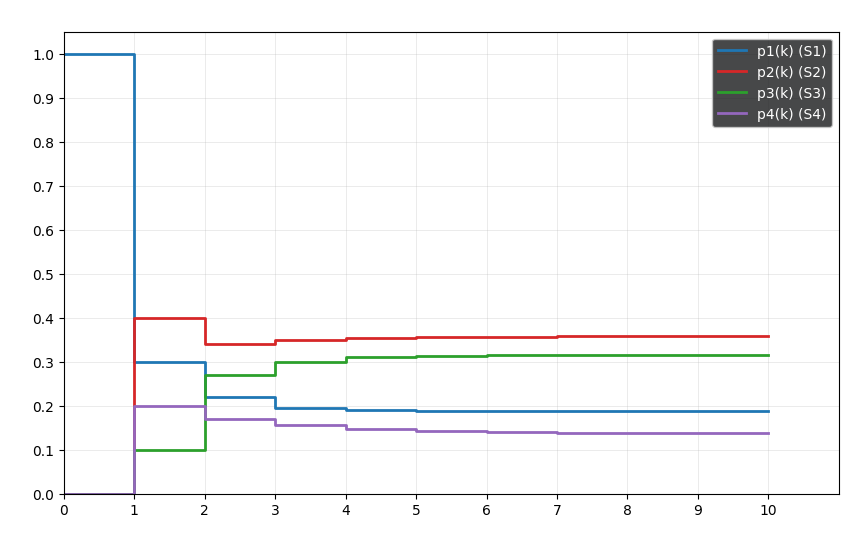

In [3]:
def plot_state_probabilities(df, graph_type="step", final_probabilities=None):
    if graph_type not in {"step", "plot"}:
        raise ValueError("graph_type має бути 'step' або 'plot'")

    fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
    ax.set_facecolor("white")

    states = ["S1", "S2", "S3", "S4"]
    state_colors = {
        "S1": "#1f77b4",
        "S2": "#d62728",
        "S3": "#2ca02c",
        "S4": "#9467bd"
    }
    final_colors = {
        "S1": "#6baed6",
        "S2": "#fb6a4a",
        "S3": "#74c476",
        "S4": "#b39ddb"
    }

    for i, state in enumerate(states, start=1):
        if graph_type == "step":
            ax.step(df["Крок"], df[state], where="post", color=state_colors[state], linewidth=2, label=f"p{i}(k) ({state})")
        else:
            ax.plot(df["Крок"], df[state], marker="o", color=state_colors[state], linewidth=2, label=f"p{i}(k) ({state})")

    if final_probabilities is not None:
        for i, state in enumerate(states, start=1):
            value = final_probabilities[state]
            ax.axhline(
                y=value,
                color=final_colors[state],
                linestyle="--",
                linewidth=2,
                alpha=0.8,
                label=f"p{i} фін. = {value:.4f}"
            )

    ax.set_title("Графік зміни ймовірностей станів системи")
    ax.set_xlabel("Крок")
    ax.set_ylabel("Ймовірність")
    x_ticks = list(range(int(df["Крок"].min()), int(df["Крок"].max()) + 1))
    y_ticks = np.round(np.arange(0.0, 1.01, 0.1), 1)
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f"{v:.1f}" for v in y_ticks])
    ax.set_xlim(df["Крок"].min(), df["Крок"].max() + 1)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="both", colors="black", labelsize=10)
    for spine in ax.spines.values():
        spine.set_color("black")
    ax.grid(True, alpha=0.35)
    ax.legend()
    plt.show()

plot_state_probabilities(_df, graph_type="step")

**Рисунок 2 – Ступінчастий графік зміни ймовірностей станів системи для перших 10 кроків процесу**

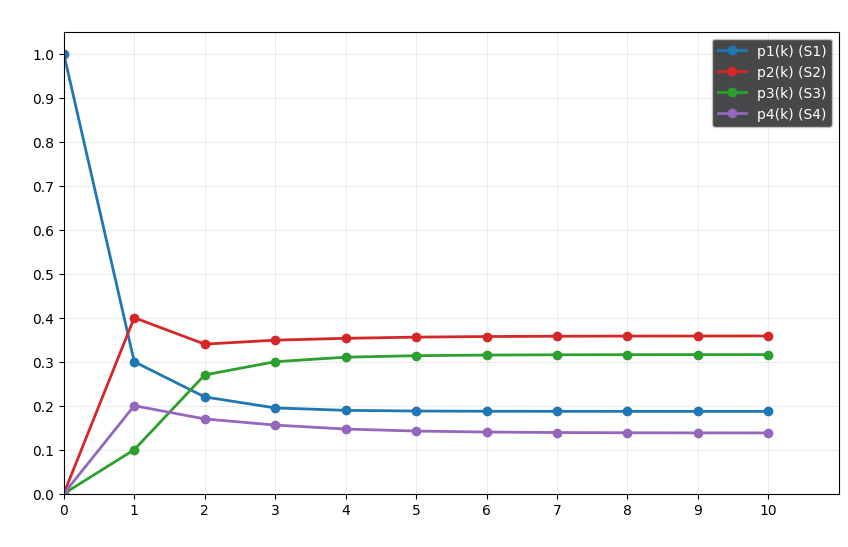

In [4]:
plot_state_probabilities(_df, graph_type="plot")

**Рисунок 3 – Лінійний графік зміни ймовірностей станів системи для перших 10 кроків процесу**

З наведених графіків видно, що на початку процесу ймовірності станів змінюються досить швидко. Особливо це помітно після першого кроку, коли ймовірність стану `S1` різко зменшується, а ймовірності інших станів зростають.

Після кількох кроків зміни ймовірностей стають значно меншими. Приблизно після 7–8 кроку значення майже не змінюються, тому можна зробити висновок, що процес наближається до усталеного режиму.

Найбільш вірогідним станом системи після 10-го кроку є стан `S2`, оскільки його ймовірність є найбільшою:

```text
p2(10) = 0.3585
```

Другим за ймовірністю є стан `S3`:

```text
p3(10) = 0.3162
```

Найменшу ймовірність має стан `S4`:

```text
p4(10) = 0.1382
```

Отже, за першими десятьма кроками можна побачити, що марківський ланцюг поступово стабілізується, а найбільш імовірним станом системи є `S2`.

## 4. Обчислення фінальних ймовірностей станів системи

Фінальні ймовірності показують, з якими ймовірностями система буде знаходитися у кожному зі станів після достатньо великої кількості кроків. Якщо процес має усталений режим, то після певного моменту ймовірності станів майже не змінюються.

Для знаходження фінальних ймовірностей використовується система:

```text
pP = p
```

де:

```text
p = [p1, p2, p3, p4]
```

— вектор фінальних ймовірностей станів системи.

Також враховується нормувальна умова:

```text
p1 + p2 + p3 + p4 = 1
```

In [5]:
# Розв'язання системи для фінальних ймовірностей
A = P.T - np.eye(4)
A[-1] = np.ones(4)

b = np.zeros(4)
b[-1] = 1

p_final = np.linalg.solve(A, b)

print("Фінальні ймовірності:")
for i, value in enumerate(p_final, start=1):
    print(f"p{i} фін. = {value:.4f}")

final_probabilities = {f"S{i}": value for i, value in enumerate(p_final, start=1)}

Фінальні ймовірності:
p1 фін. = 0.1871
p2 фін. = 0.3586
p3 фін. = 0.3163
p4 фін. = 0.1381


Після розв’язання системи отримано такі фінальні ймовірності:

```text
p1 фін. = 0.1871
p2 фін. = 0.3586
p3 фін. = 0.3163
p4 фін. = 0.1381
```

Отже, в усталеному режимі система найчастіше буде перебувати у стані `S2`, оскільки фінальна ймовірність цього стану є найбільшою:

```text
p2 фін. = 0.3586
```

Найменш імовірним в усталеному режимі є стан `S4`:

```text
p4 фін. = 0.1381
```

Фінальні ймовірності були додані на графіки у вигляді горизонтальних пунктирних ліній. Це дозволяє наочно порівняти значення ймовірностей після перших десяти кроків із фінальними значеннями.

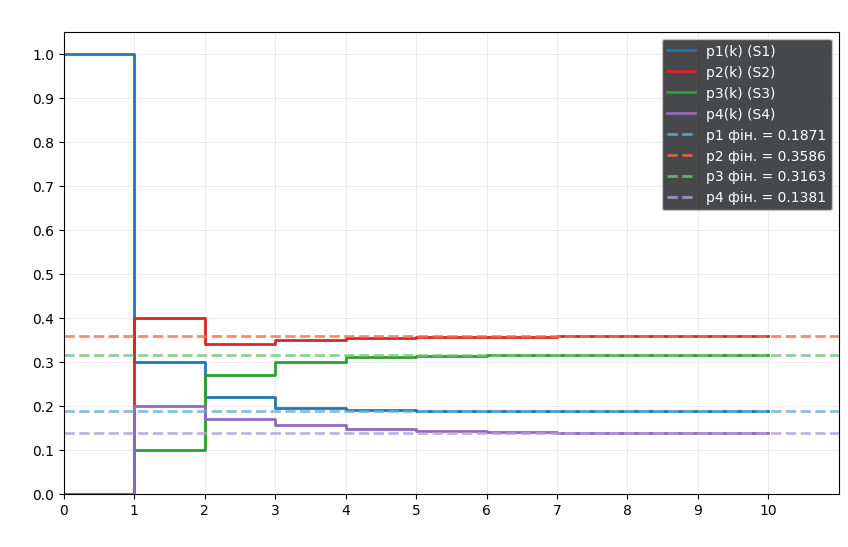

In [6]:
plot_state_probabilities(_df, graph_type="step", final_probabilities=final_probabilities)

**Рисунок 4 – Ступінчастий графік зміни ймовірностей станів системи з фінальними ймовірностями**

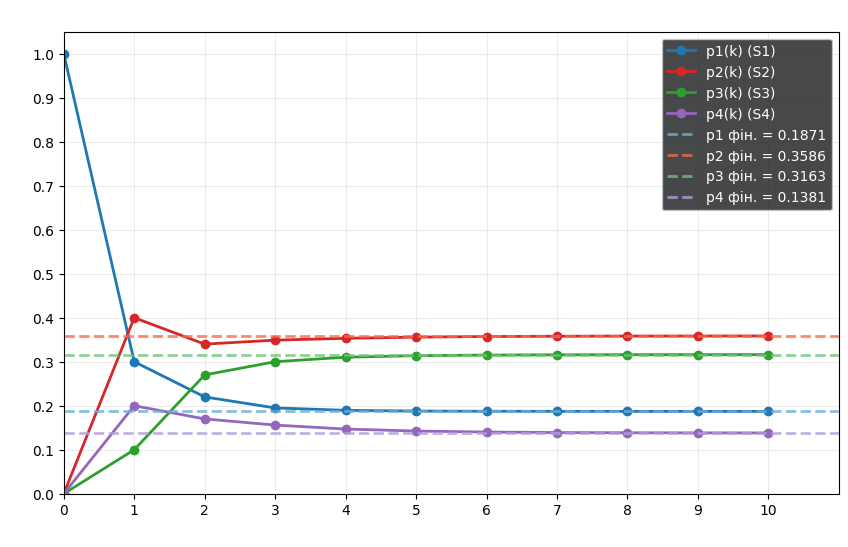

In [7]:
plot_state_probabilities(_df, graph_type="plot", final_probabilities=final_probabilities)

**Рисунок 5 – Лінійний графік зміни ймовірностей станів системи з фінальними ймовірностями**

З графіків видно, що значення ймовірностей станів після 10-го кроку практично збігаються з фінальними ймовірностями. Це означає, що система майже досягла усталеного режиму вже протягом перших десяти кроків процесу.